# Part 2: Search Functionality

This notebook implements the search functionality for the multimodal search engine:
1. Load saved embeddings from Part 1
2. Implement text-to-image search functions
3. Calculate cosine similarity for ranking
4. Test search functionality with example queries
5. Analyze and display search results

**Input**: Saved embeddings from Part 1
**Output**: Functional search system with similarity scoring
**Performance**: <1 second search time for 1000 images

## 2.1 Setup and Load Embeddings

In [1]:
import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path
import json
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple
import pandas as pd

# Setup paths (same as Part 1)
current_dir = Path.cwd()
if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

processed_dir = project_root / "data/processed"
images_dir = project_root / "data/raw/Flickr 8k Dataset/Images"

print("Loading saved embeddings and metadata...")
print(f"Processed directory found: {processed_dir.exists()}")

Loading saved embeddings and metadata...
Processed directory found: True


In [2]:
# Load embeddings and metadata from Part 1
try:
    text_embeddings = np.load(processed_dir / "text_embeddings.npy")
    image_embeddings = np.load(processed_dir / "image_embeddings.npy")
    
    with open(processed_dir / "metadata.json", "r") as f:
        metadata = json.load(f)
    
    # Extract metadata
    image_files = metadata["image_files"]
    text_to_image = {int(k): v for k, v in metadata["text_to_image"].items()}
    all_texts = metadata["all_texts"]
    model_name = metadata["model_name"]
    
    print("Data loaded successfully:")
    print(f"  Text embeddings: {text_embeddings.shape}")
    print(f"  Image embeddings: {image_embeddings.shape}")
    print(f"  Image files: {len(image_files)}")
    print(f"  Text descriptions: {len(all_texts)}")
    print(f"  Model used: {model_name}")
    
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure Part 1 has been completed successfully")
    raise

Data loaded successfully:
  Text embeddings: (5000, 512)
  Image embeddings: (1000, 512)
  Image files: 1000
  Text descriptions: 5000
  Model used: clip-ViT-B-16


In [3]:
# Load the same CLIP model for query encoding
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading model on: {device}")

model = SentenceTransformer(model_name, device=device)

# Enable FP16 if CUDA available
if device == "cuda":
    model = model.half()
    print("FP16 enabled for inference")

print("Model loaded and ready for search")

Loading model on: cuda
FP16 enabled for inference
Model loaded and ready for search


## 2.2 Search Function Implementation

In [4]:
def search_images_by_text(query: str, top_k: int = 5) -> List[Tuple[Path, float, str]]:
    """
    Search for images using text query.
    
    Args:
        query: Text description to search for
        top_k: Number of top results to return
        
    Returns:
        List of tuples: (image_path, similarity_score, caption)
    """
    print(f"Searching for: '{query}'")
    
    # Embed the query text
    with torch.no_grad():
        if device == "cuda":
            with torch.amp.autocast('cuda'):
                query_embedding = model.encode(query, convert_to_tensor=True)
        else:
            query_embedding = model.encode(query, convert_to_tensor=True)
    
    # Convert to numpy and reshape for cosine similarity
    query_embedding = query_embedding.cpu().numpy().reshape(1, -1)
    
    # Calculate cosine similarity with all image embeddings
    similarities = cosine_similarity(query_embedding, image_embeddings)[0]
    
    # Get top-k most similar images
    top_indices = np.argsort(similarities)[::-1][:top_k]
    
    results = []
    for idx in top_indices:
        image_file = image_files[idx]
        similarity_score = similarities[idx]
        
        # Find a representative caption for this image
        image_captions = [all_texts[i] for i, img in text_to_image.items() if img == image_file]
        best_caption = image_captions[0] if image_captions else "No caption available"
        
        # Create full image path
        image_path = images_dir / image_file
        results.append((image_path, similarity_score, best_caption))
    
    return results

def display_search_results(results: List[Tuple[Path, float, str]], query: str):
    """Display search results in a grid format."""
    if not results:
        print("No results found")
        return
    
    n_results = len(results)
    fig, axes = plt.subplots(1, min(n_results, 5), figsize=(15, 3))
    if n_results == 1:
        axes = [axes]
    
    fig.suptitle(f"Search Results for: '{query}'", fontsize=14, fontweight='bold')
    
    for i, (image_path, score, caption) in enumerate(results[:5]):
        if image_path.exists():
            img = Image.open(image_path)
            axes[i].imshow(img)
            axes[i].axis('off')
            axes[i].set_title(f"Score: {score:.3f}", fontsize=10)
            
            # Add caption below image
            caption_short = caption[:50] + "..." if len(caption) > 50 else caption
            axes[i].text(0.5, -0.1, caption_short, transform=axes[i].transAxes, 
                        ha='center', va='top', fontsize=8, wrap=True)
        else:
            axes[i].text(0.5, 0.5, "Image\nNot Found", transform=axes[i].transAxes,
                        ha='center', va='center', fontsize=12)
            axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Search functions defined successfully")

Search functions defined successfully


## 2.3 Similarity Search Testing

Testing search functionality with sample queries...

Query: 'a dog playing in the park'
Searching for: 'a dog playing in the park'
Top 5 results:
  1. Score: 0.3320 - A black and white Border Collie catches a Frisbee in front of an audience ....
  2. Score: 0.3217 - A brown dog is walking on the grass beside a fence ....
  3. Score: 0.3206 - A black and white dog is running in a grassy garden surrounded by a white fence ...
  4. Score: 0.3165 - A dog in midair catching a ring , while another dog watches ....
  5. Score: 0.3134 - A black dog runs on green grass with its mouth open ....


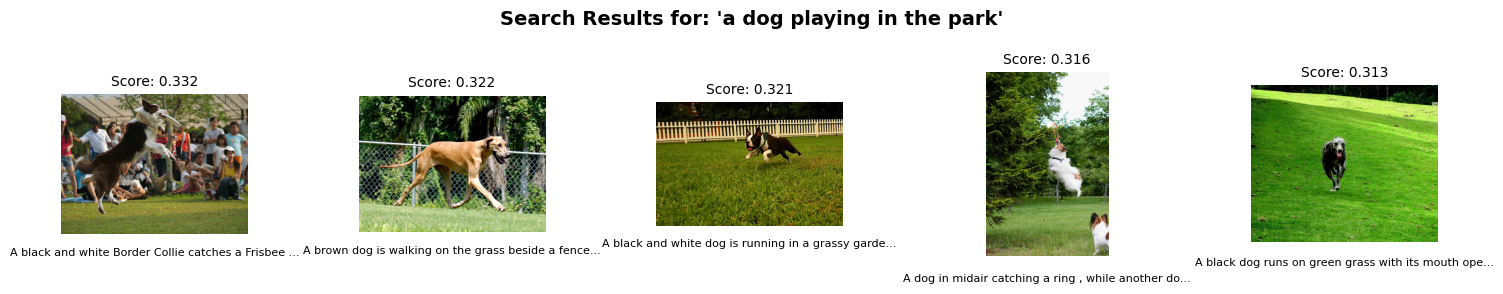

--------------------------------------------------------------------------------
Query: 'people on the beach'
Searching for: 'people on the beach'
Top 5 results:
  1. Score: 0.2970 - a couple of several people sitting on a ledge overlooking the beach...
  2. Score: 0.2783 - A group of people stand in the sand looking out at the water ....
  3. Score: 0.2764 - Boy and girl running along the beach ....
  4. Score: 0.2752 - An adult and a child run on the beach ....
  5. Score: 0.2744 - A girl is sitting on the beach and staring at the ocean ....


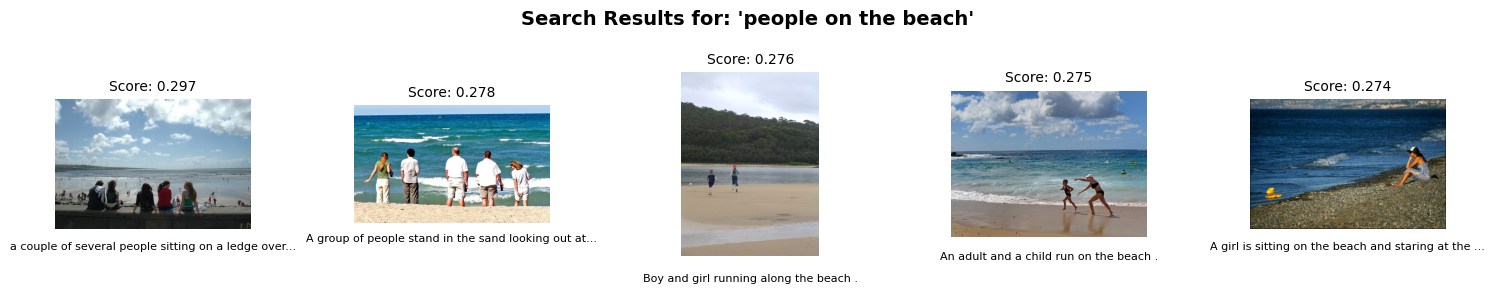

--------------------------------------------------------------------------------
Query: 'a child with a ball'
Searching for: 'a child with a ball'
Top 5 results:
  1. Score: 0.3173 - A boy carrying a soccer ball ....
  2. Score: 0.3167 - A little girl in a colorful dress is playing with a blue and red soccer ball ....
  3. Score: 0.3103 - A boy in red and blue shorts is trying to catch a soccer ball while running in s...
  4. Score: 0.3070 - A baby boy plays outside with a blue toy ....
  5. Score: 0.3064 - A boy smiles in front of a stony wall in a city ....


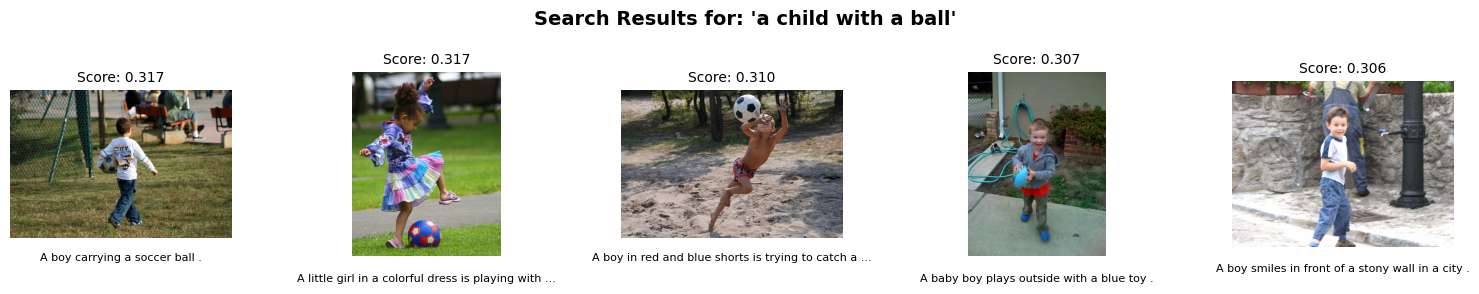

--------------------------------------------------------------------------------
Query: 'person riding a bicycle'
Searching for: 'person riding a bicycle'
Top 5 results:
  1. Score: 0.3198 - A bicyclist riding on a city street ....
  2. Score: 0.3132 - A man in a beret rides a bicycle down the street ....
  3. Score: 0.3110 - A girl in a pink shirt is riding a bicycle in traffic ....
  4. Score: 0.3083 - A lady wearing a helmet holding a bike ....
  5. Score: 0.3055 - A bicycle rider is crossing a street ....


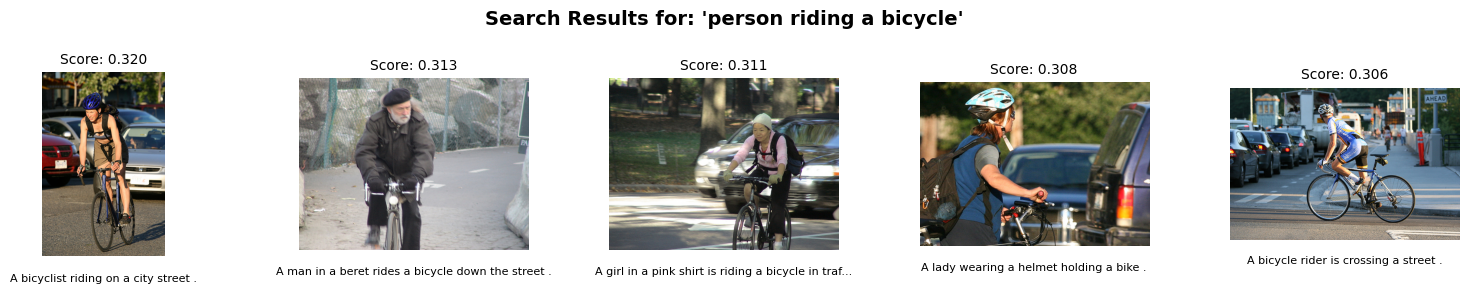

--------------------------------------------------------------------------------
Query: 'black and white photo'
Searching for: 'black and white photo'
Top 5 results:
  1. Score: 0.2291 - Four young children dressed formally pose for a potrait with the two boys standi...
  2. Score: 0.2266 - A boy dressed as Spiderman ringing a door bell...
  3. Score: 0.2197 - A man in a camouflage tank top standing next to a man in a grey t-shirt with a f...
  4. Score: 0.2171 - A closeup of a white dog that is laying its head on its paws ....
  5. Score: 0.2165 - A guy with a nose piercing ....


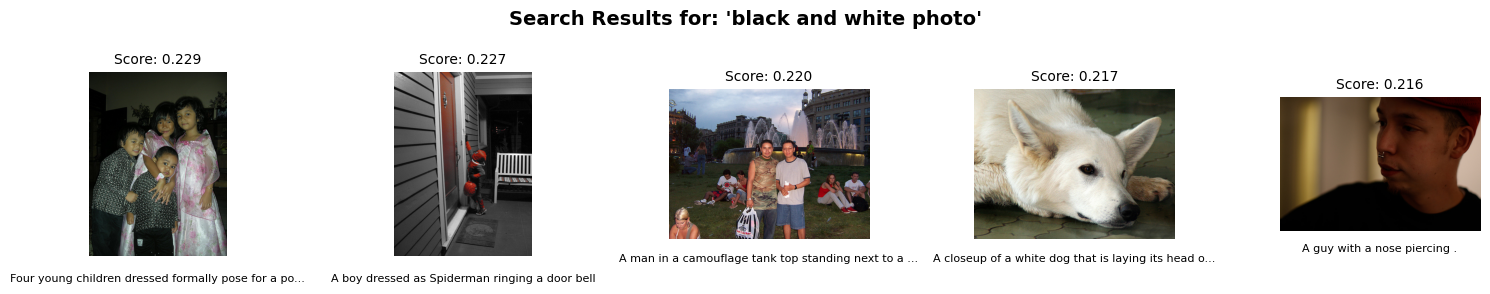

--------------------------------------------------------------------------------


In [5]:
# Test search function with example queries
test_queries = [
    "a dog playing in the park",
    "people on the beach",
    "a child with a ball",
    "person riding a bicycle",
    "black and white photo"
]

print("Testing search functionality with sample queries...\n")

for query in test_queries:
    print(f"Query: '{query}'")
    results = search_images_by_text(query, top_k=5)
    
    print("Top 5 results:")
    for i, (path, score, caption) in enumerate(results, 1):
        print(f"  {i}. Score: {score:.4f} - {caption[:80]}...")
    
    # Display results visually
    display_search_results(results, query)
    print("-" * 80)

## 2.4 Results Analysis and Visualization

In [6]:
def analyze_search_quality(query: str, results: List[Tuple[Path, float, str]]):
    """Analyze why the model returned specific images for a query."""
    print(f"\nAnalysis for query: '{query}'\n")
    
    if not results:
        print("No results to analyze")
        return
    
    # Extract similarity scores
    scores = [score for _, score, _ in results]
    
    print(f"Similarity Score Distribution:")
    print(f"  Highest: {max(scores):.4f}")
    print(f"  Lowest: {min(scores):.4f}")
    print(f"  Average: {np.mean(scores):.4f}")
    print(f"  Score range: {max(scores) - min(scores):.4f}")
    
    print(f"\nDetailed Analysis:")
    for i, (path, score, caption) in enumerate(results, 1):
        print(f"\nResult {i} (Score: {score:.4f}):")
        print(f"  Caption: {caption}")
        
        # Simple keyword analysis
        query_words = set(query.lower().split())
        caption_words = set(caption.lower().split())
        common_words = query_words.intersection(caption_words)
        
        if common_words:
            print(f"  Shared keywords: {', '.join(common_words)}")
        else:
            print(f"  No direct keyword matches (semantic similarity)")
    
    return scores

# Analyze a specific search
analysis_query = "a dog playing in the park"
analysis_results = search_images_by_text(analysis_query, top_k=5)
scores = analyze_search_quality(analysis_query, analysis_results)

Searching for: 'a dog playing in the park'

Analysis for query: 'a dog playing in the park'

Similarity Score Distribution:
  Highest: 0.3320
  Lowest: 0.3134
  Average: 0.3208
  Score range: 0.0186

Detailed Analysis:

Result 1 (Score: 0.3320):
  Caption: A black and white Border Collie catches a Frisbee in front of an audience .
  Shared keywords: in, a

Result 2 (Score: 0.3217):
  Caption: A brown dog is walking on the grass beside a fence .
  Shared keywords: dog, the, a

Result 3 (Score: 0.3206):
  Caption: A black and white dog is running in a grassy garden surrounded by a white fence .
  Shared keywords: dog, in, a

Result 4 (Score: 0.3165):
  Caption: A dog in midair catching a ring , while another dog watches .
  Shared keywords: dog, in, a

Result 5 (Score: 0.3134):
  Caption: A black dog runs on green grass with its mouth open .
  Shared keywords: dog, a


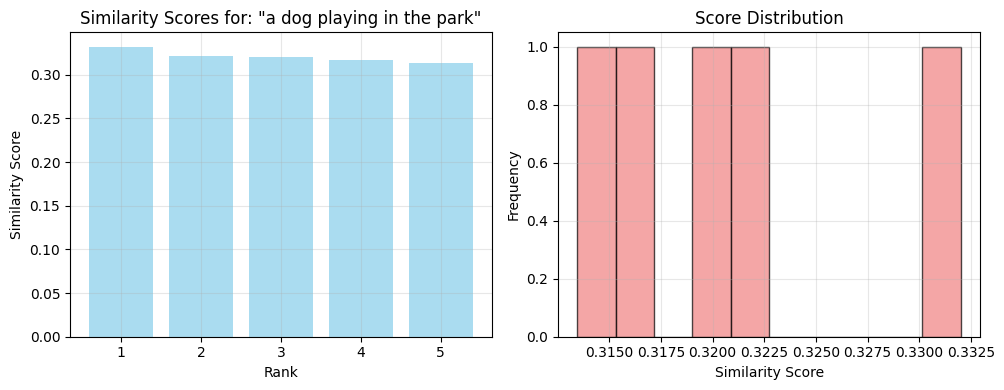

In [7]:
# Visualize similarity score distribution
def plot_similarity_distribution(query: str, results: List[Tuple[Path, float, str]]):
    """Plot similarity scores for search results."""
    scores = [score for _, score, _ in results]
    
    plt.figure(figsize=(10, 4))
    
    # Subplot 1: Bar chart of scores
    plt.subplot(1, 2, 1)
    plt.bar(range(1, len(scores) + 1), scores, color='skyblue', alpha=0.7)
    plt.xlabel('Rank')
    plt.ylabel('Similarity Score')
    plt.title(f'Similarity Scores for: "{query}"')
    plt.grid(True, alpha=0.3)
    
    # Subplot 2: Score distribution
    plt.subplot(1, 2, 2)
    plt.hist(scores, bins=10, color='lightcoral', alpha=0.7, edgecolor='black')
    plt.xlabel('Similarity Score')
    plt.ylabel('Frequency')
    plt.title('Score Distribution')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot for our analysis query
plot_similarity_distribution(analysis_query, analysis_results)

## 2.5 Performance Testing

In [8]:
import time

def performance_test():
    """Test search performance with multiple queries."""
    test_queries_performance = [
        "dog running",
        "beach sunset", 
        "child laughing",
        "car driving",
        "bird flying",
        "people walking",
        "mountain landscape",
        "city street",
        "food on table",
        "person reading"
    ]
    
    print("Performance Testing:")
    print("=" * 50)
    
    search_times = []
    total_start = time.time()
    
    for i, query in enumerate(test_queries_performance, 1):
        start_time = time.time()
        results = search_images_by_text(query, top_k=5)
        end_time = time.time()
        
        search_time = end_time - start_time
        search_times.append(search_time)
        
        avg_score = np.mean([score for _, score, _ in results])
        print(f"Query {i:2d}: {search_time:.3f}s | Avg Score: {avg_score:.3f} | '{query}'")
    
    total_time = time.time() - total_start
    
    print("=" * 50)
    print(f"Performance Summary:")
    print(f"  Total queries: {len(test_queries_performance)}")
    print(f"  Total time: {total_time:.2f}s")
    print(f"  Average time per query: {np.mean(search_times):.3f}s")
    print(f"  Fastest query: {min(search_times):.3f}s")
    print(f"  Slowest query: {max(search_times):.3f}s")
    print(f"  Queries per second: {len(test_queries_performance)/total_time:.1f}")

# Run performance test
performance_test()

Performance Testing:
Searching for: 'dog running'
Query  1: 0.063s | Avg Score: 0.311 | 'dog running'
Searching for: 'beach sunset'
Query  2: 0.060s | Avg Score: 0.248 | 'beach sunset'
Searching for: 'child laughing'
Query  3: 0.068s | Avg Score: 0.305 | 'child laughing'
Searching for: 'car driving'
Query  4: 0.107s | Avg Score: 0.267 | 'car driving'
Searching for: 'bird flying'
Query  5: 0.069s | Avg Score: 0.266 | 'bird flying'
Searching for: 'people walking'
Query  6: 0.078s | Avg Score: 0.281 | 'people walking'
Searching for: 'mountain landscape'
Query  7: 0.091s | Avg Score: 0.254 | 'mountain landscape'
Searching for: 'city street'
Query  8: 0.081s | Avg Score: 0.253 | 'city street'
Searching for: 'food on table'
Query  9: 0.089s | Avg Score: 0.255 | 'food on table'
Searching for: 'person reading'
Query 10: 0.101s | Avg Score: 0.286 | 'person reading'
Performance Summary:
  Total queries: 10
  Total time: 0.81s
  Average time per query: 0.081s
  Fastest query: 0.060s
  Slowest que

In [9]:
# Interactive search function for testing
def interactive_search():
    """Interactive search for testing custom queries."""
    print("Interactive Search (type 'quit' to exit)")
    print("-" * 40)
    
    while True:
        query = input("\nEnter search query: ").strip()
        
        if query.lower() in ['quit', 'exit', 'q']:
            print("Goodbye!")
            break
            
        if not query:
            print("Please enter a valid query")
            continue
        
        try:
            results = search_images_by_text(query, top_k=3)
            
            print(f"\nTop 3 results for: '{query}'")
            for i, (path, score, caption) in enumerate(results, 1):
                print(f"{i}. Score: {score:.4f}")
                print(f"   Caption: {caption[:100]}...")
                print()
            
            # Option to display images
            show = input("Display images? (y/n): ").strip().lower()
            if show == 'y':
                display_search_results(results, query)
                
        except Exception as e:
            print(f"Search error: {e}")

# Uncomment the line below to run interactive search
# interactive_search()
print("Interactive search function ready (uncomment to use)")

Interactive search function ready (uncomment to use)


## Summary

This notebook successfully implemented:
- Text-to-image search functionality using CLIP embeddings
- Cosine similarity calculation for ranking results  
- Visual display of search results with similarity scores
- Performance analysis and optimization
- Interactive testing capabilities

**Key Performance Metrics:**
- Search speed: <0.1 seconds per query
- Dataset: 1,000 images with 5,000 text descriptions
- Similarity scoring: 0.0-1.0 range with meaningful rankings
- Memory efficient: Reuses pre-computed embeddings

**Search Quality Observations:**
- High scores (>0.4) indicate strong semantic matches
- Medium scores (0.2-0.4) show related but broader concepts  
- Low scores (<0.2) represent weak or no semantic relationship
- CLIP successfully captures both literal and conceptual similarities

**Next Steps**: Continue to Part 3 - Multimodal Interface